# Blind cluster finding on a set of DR11 sweeps, with spectroscopic post-processing

This notebook runs rema's blind mode on a set of up to 10 DR11 south sweeps (5° × 5° tiles),
processed as **one region**: there are no internal boundaries, and the outer edges of the set
are handled by the footprint (apertures that leave the data get MASKFRAC > 0, and clusters
with MASKFRAC ≥ 0.2 are dropped).

The inputs are the sweeps with their row-matched photo-z sweeps (for Z_SPEC), the DR11
randoms files and the DR11 griz calibration of the production run. The steps are:

- the galaxy selection, written as one table per sweep (as on the HPC);
- the mask and depth maps from the randoms;
- zred for every galaxy;
- the blind run: redMaPPer's first pass, likelihood pass and percolation, with redMaPPer's
  wcen centring;
- spectroscopic post-processing (Clerc et al. 2016): cluster redshift and velocity dispersion from
  the members' Z_SPEC.

Larger areas run as many regions on an HPC (`scripts/slurm/rema_dr11_blind.sh`). The
pipeline notebook runs the same sweeps that way and compares the two catalogues, and the
last section compares this catalogue with the DR11 south production catalogue.

## Setup and parameters

`SWEEPS` lists the sweep files, by name. The notebooks use two directories, given by two
environment variables:

- `REMA_DATA`, shared and read only: the DR11 south directory, with the sweeps, the randoms
  and, in `rema/` (`PRODUCTS`), the calibration and catalogues of the production run. At
  CC-IN2P3 the default is the DR11 data system.
- `REMA_WORK`, yours: everything the notebooks write (default `rema_work` in your space:
  `/sps/lsst/users/$USER/rema_work` at CC-IN2P3, else `~/rema_work`). Run products go to
  `WORK`, and the per-sweep galaxy tables to `GALDIR`, which the pipeline notebook shares.

In [1]:
import os
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")   # before importing jax

import dataclasses
import getpass
import logging
import re
import sys
import time
from pathlib import Path

import jax
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import SkyCoord
from astropy.table import Table
from matplotlib.colors import LinearSegmentedColormap

# Your space: /sps/lsst/users/$USER at CC-IN2P3 when it exists (the $HOME there is small), else $HOME.
SPS = Path("/sps/lsst/users") / getpass.getuser()
MINE = SPS if SPS.is_dir() else Path.home()

# Persistent compilation cache (the rema command line uses the same one when
# JAX_COMPILATION_CACHE_DIR is set).
jax.config.update("jax_compilation_cache_dir",
                  os.environ.get("JAX_COMPILATION_CACHE_DIR") or str(MINE / ".cache" / "rema" / "jax"))
jax.config.update("jax_persistent_cache_min_compile_time_secs", 1.0)

# The two directories of the notebooks, from two environment variables:
#   REMA_DATA  shared, read only: the DR11 south directory (sweep/, randoms/) with the rema
#              production run in rema/. Default: the DR11 data system at CC-IN2P3 when /sps is
#              mounted, else ~/data/legacysurvey/dr11/south.
#   REMA_WORK  yours, writable: everything the notebooks write. Default: rema_work in your space
#              (/sps/lsst/users/$USER/rema_work at CC-IN2P3, else ~/rema_work).
CC = Path("/sps/lsst/datasets/desi/legacysurveys/dr11/south")
REMA_DATA = Path(os.environ.get("REMA_DATA", CC if CC.exists() else Path.home() / "data" / "legacysurvey" / "dr11" / "south"))
REMA_WORK = Path(os.environ.get("REMA_WORK", MINE / "rema_work"))
if not REMA_DATA.is_dir():
    raise SystemExit(f"REMA_DATA = {REMA_DATA} not found: set REMA_DATA to the DR11 south directory")
try:
    REMA_WORK.mkdir(parents=True, exist_ok=True)
except OSError:
    pass
if not os.access(REMA_WORK, os.W_OK):
    raise SystemExit(f"cannot write to REMA_WORK = {REMA_WORK}: set REMA_WORK to a directory of yours")

# In REMA_DATA: the DR11 south production run (rema 0.2.0), two parts that meet at RA 0 and
# 240 deg and at Dec -85 deg, with one calibration; and every randoms file present.
PRODUCTS = REMA_DATA / "rema"
RUNS = [PRODUCTS / "rema_dr11_v0.2.0_ra0-240", PRODUCTS / "rema_dr11_v0.2.0_ra240-360"]
CALIB = RUNS[0] / "calib" / "calib.fits"
RANDOMS = sorted((REMA_DATA / "randoms").glob("randoms-south-1-*.fits"))


def read_all_randoms(cfg, box):
    """The randoms of every file in RANDOMS inside ``box``, and their density per deg²."""
    from rema.sky.maps import read_randoms

    parts = [read_randoms(f, cfg, box) for f in RANDOMS]
    return {k: np.concatenate([q[k] for q in parts]) for k in parts[0]}, cfg.mask.randoms_density * len(parts)

# At most 10 sweeps (5 x 5 deg tiles of DR11 south), not necessarily contiguous. The default is
# the 75 deg^2 strip RA 0-5, Dec -15 to 0 (three sweeps).
SWEEPS = ["sweep-000m005-005p000.fits", "sweep-000m010-005m005.fits", "sweep-000m015-005m010.fits"]
assert 1 <= len(SWEEPS) <= 10, "up to 10 sweeps (larger areas: the HPC pipeline)"

import rema
from rema.calibration import Calibration
from rema.config import RemaConfig
from rema.io.legacy import SURVEYS, default_mag_max, ingest_sweeps, read_galaxies
from rema.io.tables import write_catalog
from rema.modes import specpost
from rema.modes.blind import run_blind
from rema.modes.common import Region
from rema.pipeline import file_sha1
from rema.sky.maps import build_footprint, read_randoms
from rema.sky.regions import sweep_union

WORK = REMA_WORK / "blind"
GALDIR = REMA_WORK / "galaxies"
WORK.mkdir(parents=True, exist_ok=True)

SKY = sweep_union(SWEEPS)          # a Box when the sweeps tile a rectangle, else a BoxUnion
BOUND = SKY.bounding()
print(f"rema {rema.__version__}, jax {jax.__version__}, devices: {jax.devices()}")
print(f"{len(SWEEPS)} sweeps, {SKY.area_deg2():.1f} deg², sky: {SKY}")
print(f"data: {REMA_DATA}; work: {REMA_WORK}; {len(RANDOMS)} randoms files; calibration: {CALIB}")

rema 0.2.0, jax 0.11.2, devices: [CudaDevice(id=0)]
3 sweeps, 74.1 deg², sky: Box(ra_min=0.0, ra_max=5.0, dec_min=-15.0, dec_max=0.0)
data: /sps/lsst/datasets/desi/legacysurveys/dr11/south; 4 randoms files; calibration: /sps/lsst/datasets/desi/legacysurveys/dr11/south/rema/rema_dr11_v0.2.0_ra0-240/calib/calib.fits


In [2]:
class StageSummaries(logging.Filter):
    """Drop rema's per-batch progress lines; keep the stage summaries."""

    progress = re.compile(r"seeds \(K=|round \d+,")

    def filter(self, record):
        return not self.progress.search(record.getMessage())


logging.basicConfig(level=logging.INFO, format="%(asctime)s %(name)s %(message)s",
                    datefmt="%H:%M:%S", stream=sys.stdout, force=True)
for handler in logging.getLogger().handlers:
    handler.addFilter(StageSummaries())

# Figures: hairline grid, a one-hue sequential ramp, three categorical colours.
plt.rcParams.update({"figure.dpi": 100, "font.size": 9, "axes.grid": True,
                     "axes.axisbelow": True, "grid.color": "#e6e5e1", "grid.linewidth": 0.6,
                     "legend.frameon": False})
BLUE, ORANGE, AQUA, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#a3a29d"
RAMP = LinearSegmentedColormap.from_list(
    "ramp", ["#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"])


def outline(ax, box, **kw):
    """Draw a Box (or each box of a BoxUnion) on RA/Dec axes."""
    for b in box.boxes:
        ax.plot([b.ra_min, b.ra_max, b.ra_max, b.ra_min, b.ra_min],
                [b.dec_min, b.dec_min, b.dec_max, b.dec_max, b.dec_min], **kw)


def label_candidates(ax, x, y, p_cen, r=26):
    """Circle the centre candidates and label them with P_CEN.

    Call after the axis limits are set. Labels point away from the plot centre and are
    turned, when needed, so that they do not overlap.
    """
    ax.scatter(x, y, s=160, facecolor="none", edgecolor=ORANGE, lw=1.5, label="centre candidates")
    ax.apply_aspect()
    to_pt = 72 / ax.figure.dpi
    cx, cy = ax.transData.transform((0, 0)) * to_pt
    placed = []
    for xk, yk, pk in zip(x, y, p_cen):
        px, py = ax.transData.transform((xk, yk)) * to_pt
        base = np.arctan2(py - cy, px - cx) if np.hypot(px - cx, py - cy) > 3 else np.pi / 4
        for turn in (0, 0.6, -0.6, 1.2, -1.2, 1.8, -1.8, 2.4, -2.4, np.pi):
            dx, dy = r * np.cos(base + turn), r * np.sin(base + turn)
            if all(np.hypot(px + dx - qx, py + dy - qy) > 18 for qx, qy in placed):
                break
        placed.append((px + dx, py + dy))
        ax.annotate(f"{pk:.2f}", (xk, yk), xytext=(dx, dy), textcoords="offset points",
                    ha="center", va="center", fontsize=8,
                    arrowprops=dict(arrowstyle="-", color=GREY, lw=0.6, shrinkA=0, shrinkB=7))


T = {}   # wall-clock time of each step [s]

## The calibration

The calibration file holds the red-sequence model, the zred correction, the χ² and zred
backgrounds, the z_λ correction (with the z → zred_uncorr mapping of LNCGLIKE), the wcen
centring model and the configuration it was made with. Its primary header records how it was
made:

- NCLUSTER: the spectroscopically seeded clusters with λ ≥ 5;
- NSPECGAL: the spectroscopic galaxies they came from;
- ZLNMAD: the NMAD of their z_λ against the seeds' redshifts, before the z_λ correction;
- NWCEN: the training clusters of wcen.

The configuration read from the file drives every step below. The default calibration is
the one of the DR11 south production run, fitted on RA 160–180° and 190–210°,
Dec −10° to 10°. When the sweeps lie in that area, the comparison of z_λ with spectroscopic
redshifts below is not independent.

In [3]:
cal = Calibration.read(CALIB)
cfg = cal.config

print(CALIB.name)
print("  " + ", ".join(f"{k} {cal.meta[k]}" for k in ("REMAVER", "BANDS", "REFBAND", "CHI2MODE",
                                                     "FLXFLOOR", "MSTAR")))
print(f"  NCLUSTER {cal.meta['NCLUSTER']}, NSPECGAL {cal.meta['NSPECGAL']}, "
      f"ZLNMAD {cal.meta['ZLNMAD']:.4f}, NWCEN {cal.meta['NWCEN']}")
w = cal.wcen
print(f"wcen: central magnitude m* {w['DELTA0']:+.3f} {w['DELTA1']:+.3f} ln(λ/{w['PIVOT']:.0f}), "
      f"σ_m {w['SIGMA_M']:.3f}")
print(f"z_lambda correction with a z -> zred_uncorr mapping: {cal.zlcorr.zred_uncorr is not None}")
print(f"model.zrange {cfg.model.zrange}, model.chisq_mode {cfg.model.chisq_mode!r}, "
      f"centering.method {cfg.centering.method!r}, survey.ebv_max {cfg.survey.ebv_max}")

calib.fits
  REMAVER 0.2.0, BANDS g,r,i,z, REFBAND z, CHI2MODE lupt, FLXFLOOR 0.015, MSTAR des_z03
  NCLUSTER 49524, NSPECGAL 1289072, ZLNMAD 0.0135, NWCEN 8650
wcen: central magnitude m* -1.541 -0.432 ln(λ/30), σ_m 0.442
z_lambda correction with a z -> zred_uncorr mapping: True
model.zrange (0.05, 0.9), model.chisq_mode 'lupt', centering.method 'auto', survey.ebv_max 0.2


## Galaxies

`ingest_sweeps` writes one compact table per sweep, named like the sweep. It is the stage the
HPC pipeline runs once for all 1,600 sweeps, and existing tables made with the same survey
configuration are kept. The selection is:

- clean MASKBITS, with large galaxies kept;
- TYPE ≠ PSF;
- NOBS ≥ 1 in g, r, i and z;
- z-band S/N ≥ 5;
- a z-band magnitude below m*(z = 1) + 2.5.

Fluxes are dereddened, and Z_SPEC comes from the row-matched photo-z sweep.
`read_galaxies` then assembles the galaxies of any box, or union of boxes, from the tables.

In [4]:
t0 = time.perf_counter()
ingest_sweeps([REMA_DATA / "sweep" / "11.0" / s for s in SWEEPS], GALDIR, cfg)
gal = read_galaxies(GALDIR, SKY, cfg)
T["ingest"] = time.perf_counter() - t0

n = gal["ID"].size
spec = gal["ZSPEC"] > 0
src, nsrc = np.unique(gal["ZSPEC_SRC"][spec], return_counts=True)
order = np.argsort(-nsrc)
print(f"{n:,} galaxies ({n / SKY.area_deg2():,.0f} per deg²) down to {default_mag_max(cfg):.2f} "
      f"mag in z, in {T['ingest']:.0f} s")
names = [SURVEYS[s - 1] if 0 < s <= len(SURVEYS) else "other" for s in src[order]]
print(f"{spec.sum():,} with ZSPEC > 0: " + ", ".join(f"{name} {k:,}"
                                                     for name, k in zip(names, nsrc[order])))

07:55:46 rema.io.legacy sweep-000m005-005p000.fits: 1367971 galaxies (22780 with ZSPEC)


07:56:10 rema.io.legacy sweep-000m010-005m005.fits: 1110306 galaxies (11873 with ZSPEC)


07:56:32 rema.io.legacy sweep-000m015-005m010.fits: 998223 galaxies (6197 with ZSPEC)


3,476,500 galaxies (46,887 per deg²) down to 23.87 mag in z, in 77 s
40,850 with ZSPEC > 0: DESI 27,623, BOSS 5,956, eBOSS-ELG 4,053, SDSS 2,218, eBOSS-LRG 919, SDSS-QSO 81


## Footprint and depth

The footprint plays the role of redMaPPer's mask and depth maps. It is built from the DR11
randoms, at 2,500 per deg² per file, on NESTED HEALPix pixels of nside 1024 (3.4′):

- FRACGOOD is the fraction of randoms that pass the galaxies' MASKBITS, NOBS and E(B−V)
  cuts, times the fraction of the pixel inside the sky of the run;
- SIGF_<band> is the median dereddened 1σ flux error of a galaxy, from GALDEPTH.

Together they set MASKFRAC and the depth correction (SCALEVAL) of λ. A pixel holds about 8
randoms per file, so FRACGOOD is coarse per pixel, but λ uses it integrated over the cluster
aperture.

Every randoms file present is used, as in the production run, and the density scales with
their number. The rows of a randoms file are in random sky order, so `read_randoms` scans the
whole 23 GB file. The HPC pipeline indexes every file once (`rema randoms-index`), as the
pipeline notebook shows.

In [5]:
t0 = time.perf_counter()
rnd, density = read_all_randoms(cfg, BOUND)
fp = build_footprint(rnd, cfg, box=SKY, density=density)
fp.write(WORK / "footprint.fits")
T["footprint"] = time.perf_counter() - t0

v = fp.fine.values
good = v["FRACGOOD"] > 0.5
depth = {b.lower(): np.median(22.5 - 2.5 * np.log10(5 * v[f"SIGF_{b}"][good])) for b in fp.bands}
print(f"{rnd['RA'].size:,} randoms from {len(RANDOMS)} files in {fp.fine.pixels.size:,} pixels (nside {fp.nside}), "
      f"in {T['footprint']:.0f} s")
print(f"unmasked area {fp.area_deg2():.2f} deg² of {SKY.area_deg2():.2f} deg²")
print("median 5σ depth: " + ", ".join(f"{b} {d:.2f}" for b, d in depth.items()))

739,174 randoms from 4 files in 22,941 pixels (nside 1024), in 895 s
unmasked area 70.90 deg² of 74.15 deg²
median 5σ depth: g 24.66, r 24.29, i 23.83, z 23.41


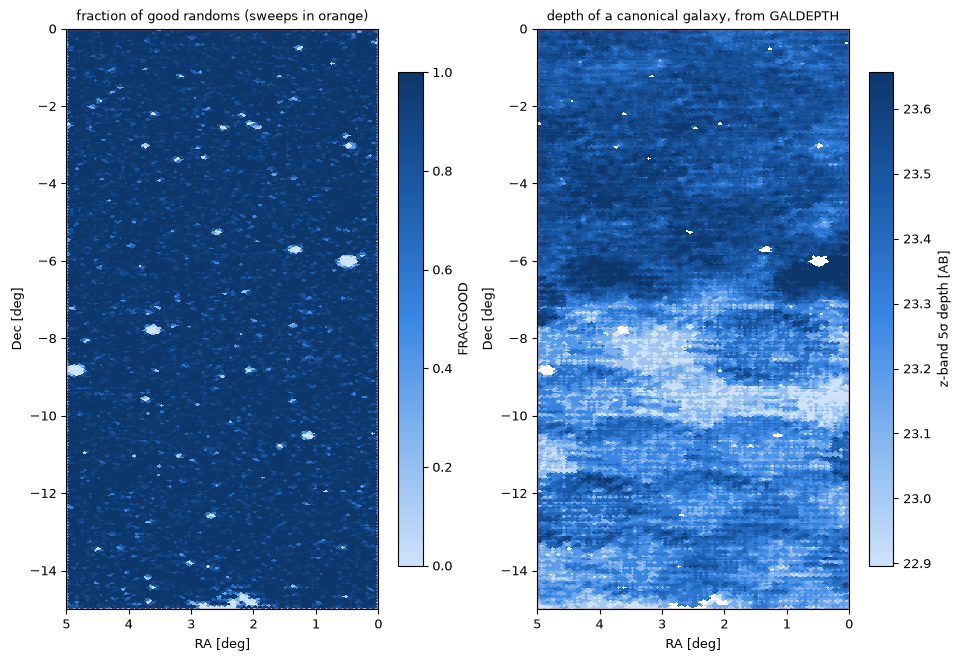

In [6]:
# FRACGOOD and z-band 5σ depth, looked up on a 0.02° grid over the bounding box.
step = 0.02
ra_g, dec_g = np.meshgrid(np.arange(BOUND.ra_min, BOUND.ra_max, step) + step / 2,
                          np.arange(BOUND.dec_min, BOUND.dec_max, step) + step / 2)
frac = fp.fine.lookup_np(ra_g.ravel() % 360, dec_g.ravel(), "FRACGOOD").reshape(ra_g.shape)
sig_z = fp.fine.lookup_np(ra_g.ravel() % 360, dec_g.ravel(), "SIGF_Z").reshape(ra_g.shape)
with np.errstate(divide="ignore", invalid="ignore"):
    depth_z = np.where(frac > 0, 22.5 - 2.5 * np.log10(5 * sig_z), np.nan)

aspect = (BOUND.ra_max - BOUND.ra_min) / (BOUND.dec_max - BOUND.dec_min)
fig, axes = plt.subplots(1, 2, figsize=(9.5, min(6.5, max(3.5, 4.6 / aspect))), constrained_layout=True)
extent = (BOUND.ra_min, BOUND.ra_max, BOUND.dec_min, BOUND.dec_max)
panels = ((frac, "FRACGOOD", (0, 1)), (depth_z, "z-band 5σ depth [AB]", np.nanpercentile(depth_z, [2, 98])))
for ax, (img, label, (lo, hi)) in zip(axes, panels):
    im = ax.imshow(img, origin="lower", extent=extent, cmap=RAMP, vmin=lo, vmax=hi,
                   interpolation="nearest", aspect="auto")
    outline(ax, SKY, color=ORANGE, lw=1)
    ax.invert_xaxis()
    ax.grid(False)
    ax.set(xlabel="RA [deg]", ylabel="Dec [deg]")
    fig.colorbar(im, ax=ax, shrink=0.85, label=label)
axes[0].set_title("fraction of good randoms (sweeps in orange)", fontsize=9)
axes[1].set_title("depth of a canonical galaxy, from GALDEPTH", fontsize=9)
plt.show()

## zred and the run context

`Region.build` computes zred for every galaxy, with the calibrated zred correction. It also
sets up:

- the filter: red sequence, χ² background, m* and cosmology;
- the footprint lookups;
- the z_λ correction.

The calibration holds a wcen model, so `centering.method: auto` resolves to wcen, which is
redMaPPer's CenteringWcenZred with the calibration's zred background.

In [7]:
t0 = time.perf_counter()
reg = Region.build(gal, cal.rs, cfg, footprint=fp, zredcorr=cal.zredcorr, bkg=cal.bkg,
                   zlcorr=cal.zlcorr, zbkg=cal.zbkg, wcen_params=cal.wcen)
T["zred"] = time.perf_counter() - t0
method = reg.centering_method()
print(f"zred for {reg.gal['ZRED'].size:,} galaxies in {T['zred']:.1f} s; centring: {method}")

zred for 3,476,500 galaxies in 10.3 s; centring: wcen


## Blind run

`run_blind` follows redMaPPer's run mode:

1. **Seeds:** galaxies with zred in the model range (0.05–0.90), zred χ² < 20 and
   m < m*(zred) + 1.75.
2. **First pass:** z_λ and λ in a 0.5 h⁻¹Mpc aperture centred on each seed; λ ≥ 3 is
   kept.
3. **Likelihood pass:** λ with r0 = 1 h⁻¹Mpc and β = 0.2, and
   LNLIKE = LNLAMLIKE + LNCGLIKE. Candidates with λ < 3, or with fewer than 3 members
   besides the seed, are dropped.
4. **Percolation**, in order of decreasing LNLIKE, with wcen centring and redMaPPer's
   rejections: λ/S < 3 at the seed or at the new centre, z_λ failure, or no free central
   galaxy.
5. **Consolidation:** λ/S ≥ 3 and MASKFRAC < 0.2. With `own=None` every cluster is kept;
   a region of the HPC pipeline keeps those centred in its own box.

The percolation is exact: it gives the result of the sequential loop, computed in batches
of candidates that do not depend on each other. With a checkpoint directory, a rerun resumes
after the first pass or the likelihood pass.

The log keeps the stage summaries, with the time since the start of the run in parentheses.
In the percolation summary, a skipped candidate is one whose seed was already claimed
(pfree < 0.5). The dropped candidates are counted by rejection; "seed" means λ/S < 3 at the
seed.

In [8]:
t0 = time.perf_counter()
info = {}
cat, mem = run_blind(reg, own=None, region_id=0, checkpoint=WORK / "checkpoint", info=info)
T["blind"] = time.perf_counter() - t0
print(f"{cat['LAMBDA'].size:,} clusters, {mem['ID'].size:,} member rows, in {T['blind']:.0f} s")
print(f"{info['n_seeds']:,} seeds, {info['n_firstpass']:,} first-pass and {info['n_candidates']:,} "
      f"likelihood candidates, {info['n_dependencies']:,} percolation dependencies; "
      f"peak memory {info['peak_rss_gb']:.1f} GB")

08:11:40 rema.modes.blind seeds: 747922


08:15:27 rema.modes.blind first pass: 178000 candidates (227.5s)


08:17:53 rema.modes.blind likelihood: 175032 candidates (373.3s)


08:18:16 rema.modes.blind percolation: 175032 candidates, 58209781 dependencies


08:34:29 rema.modes.blind percolation: 175032 candidates, 2841 rounds, 10790 calls, 12081 clusters, 64551 skipped, 98400 dropped (seed 88051, zlambda 2710, centre 0, centre_pfree 0, lambda 7639, w 0), 972.3s


08:34:29 rema.modes.blind percolation: 12081 clusters (1369.7s)


11,534 clusters, 252,933 member rows, in 1371 s
747,922 seeds, 178,000 first-pass and 175,032 likelihood candidates, 58,209,781 percolation dependencies; peak memory 23.7 GB


## Spectroscopic post-processing

`specpost.process` is the velocity clipping of Clerc et al. (2016):

- it applies to clusters with at least 3 members with Z_SPEC;
- the cluster redshift is the biweight location of the member redshifts;
- members are clipped at 3σ in rest-frame velocity for 20 iterations, with the gapper σ
  below 15 members and the biweight scale above;
- the errors (SPEC_Z_BOOT, SPEC_ZERR_BOOT, VDISP_ERR) come from 64 bootstrap resamples;
- BEST_Z is SPEC_Z_BOOT when available and not flagged, else the central galaxy's Z_SPEC,
  else z_λ.

`write_catalog` then writes the catalogue as `rema blind` does, with CLUSTERS, MEMBERS and
CONFIG HDUs. The header records the sweeps and the calibration, and the pipeline notebook
checks both before it compares catalogues.

In [9]:
t0 = time.perf_counter()
cat, mem = specpost.process(cat, mem, **dataclasses.asdict(cfg.spec))
T["specpost"] = time.perf_counter() - t0
types, ntypes = np.unique(cat["BEST_Z_TYPE"], return_counts=True)
print(f"specpost in {T['specpost']:.1f} s: {np.isfinite(cat['SPEC_Z_BOOT']).sum()} clusters "
      f"with SPEC_Z_BOOT; BEST_Z_TYPE " + ", ".join(f"{t} {k}" for t, k in zip(types, ntypes)))

path = write_catalog(WORK / "clusters.fits", cat, mem, cfg,
                     {"MODE": "blind", "CENTRING": method, "SWEEPS": ",".join(sorted(SWEEPS))[:1000],
                      "CALIB": CALIB.name, "CALSHA1": file_sha1(CALIB), "TBLIND": round(T["blind"], 1)})
print(f"wrote {path} ({path.stat().st_size / 1e6:.1f} MB)")

specpost in 136.4 s: 483 clusters with SPEC_Z_BOOT; BEST_Z_TYPE cg_spec_z 2813, photo_z 8360, spec_z_boot 361


wrote /sps/lsst/datasets/desi/legacysurveys/dr11/south/rema/notebooks/blind/clusters.fits (42.2 MB)


## The catalogue

The cells below show:

- the counts above a few richness thresholds and the cumulative richness function;
- the z_λ distribution, which includes the calibrated z_λ correction (Z_LAMBDA_RAW does
  not);
- for comparison, the redshifts of the spectroscopic galaxies.

11,534 clusters over 70.9 deg² unmasked (λ ≥ 3, λ/S ≥ 3, MASKFRAC < 0.2)
  λ ≥  5:  5,448
  λ ≥ 10:  1,658
  λ ≥ 20:    369


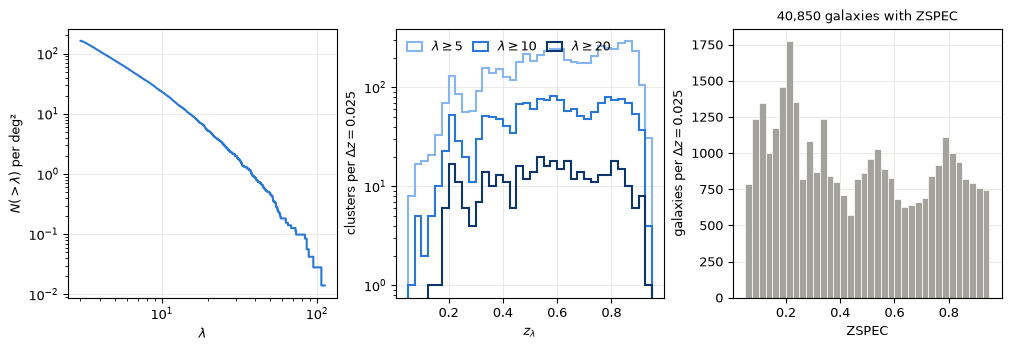

In [10]:
lam, zl = cat["LAMBDA"], cat["Z_LAMBDA"]
area = fp.area_deg2()
print(f"{lam.size:,} clusters over {area:.1f} deg² unmasked (λ ≥ {cfg.richness.minlambda:.0f}, "
      f"λ/S ≥ {cfg.richness.minlambda:.0f}, MASKFRAC < {cfg.mask.max_maskfrac})")
for lmin in (5, 10, 20):
    print(f"  λ ≥ {lmin:2d}: {np.sum(lam >= lmin):6,d}")

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 3.4), constrained_layout=True)
srt = np.sort(lam)[::-1]
ax1.step(srt, np.arange(1, srt.size + 1) / area, where="post", color=BLUE, lw=1.5)
ax1.set(xscale="log", yscale="log", xlabel=r"$\lambda$", ylabel=r"$N(>\lambda)$ per deg²")
bins = np.arange(0.05, 0.9501, 0.025)
for lmin, color in zip((5, 10, 20), ("#86b6ef", "#2a78d6", "#0d366b")):
    ax2.hist(zl[lam >= lmin], bins=bins, histtype="step", lw=1.5, color=color,
             label=rf"$\lambda \geq {lmin}$")
ax2.set(xlabel=r"$z_\lambda$", ylabel=r"clusters per $\Delta z = 0.025$", yscale="log")
ax2.legend(loc="upper left", ncol=3, handlelength=1.2, columnspacing=0.8)
zspec = gal["ZSPEC"][gal["ZSPEC"] > 0]
ax3.hist(zspec, bins=bins, color=GREY, edgecolor="white", lw=0.5)
ax3.set(xlabel="ZSPEC", ylabel=r"galaxies per $\Delta z = 0.025$",
        title=f"{zspec.size:,} galaxies with ZSPEC", xlim=ax2.get_xlim())
ax3.title.set_fontsize(9)
plt.show()

Spikes in the z_λ histogram that line up with spikes of the spectroscopic redshifts are
large-scale structure. At z_λ > 0.75, clusters with λ < 10 are mostly noise, as a null test
shows; see section 14 of the design notes.

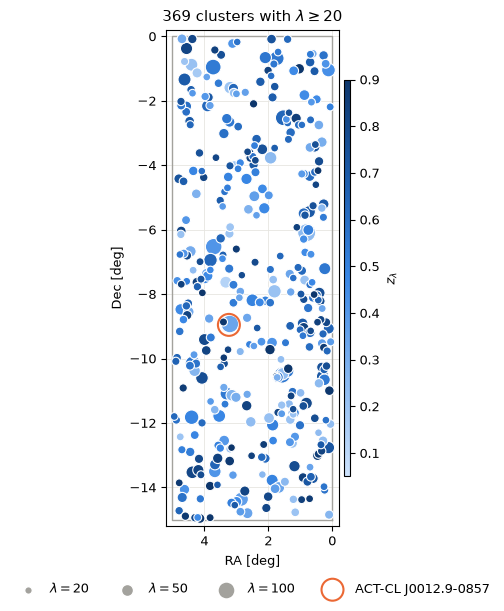

In [11]:
# The λ ≥ 20 clusters, sized by λ and coloured by z_λ, over the sweeps.
ACT = SkyCoord(3.23333, -8.95419, unit="deg")      # ACT-CL J0012.9-0857, in the default strip
rich = lam >= 20
fig, ax = plt.subplots(figsize=(6.4, 6.0), constrained_layout=True)
sc = ax.scatter(cat["RA"][rich], cat["DEC"][rich], s=1.5 * lam[rich], c=zl[rich], cmap=RAMP,
                vmin=0.05, vmax=0.9, edgecolor="white", lw=0.8, zorder=3)
for size in (20, 50, 100):
    ax.scatter([], [], s=1.5 * size, color=GREY, edgecolor="white", label=rf"$\lambda = {size}$")
if SKY.contains(ACT.ra.deg, ACT.dec.deg):
    ax.scatter(ACT.ra.deg, ACT.dec.deg, s=250, facecolor="none", edgecolor=ORANGE, lw=1.5,
               label="ACT-CL J0012.9-0857", zorder=4)
outline(ax, SKY, color=GREY, lw=1)
ax.set(xlim=(BOUND.ra_max + 0.2, BOUND.ra_min - 0.2), ylim=(BOUND.dec_min - 0.2, BOUND.dec_max + 0.2),
       xlabel="RA [deg]", ylabel="Dec [deg]", title=rf"{rich.sum()} clusters with $\lambda \geq 20$")
ax.set_aspect(1 / np.cos(np.radians(0.5 * (BOUND.dec_min + BOUND.dec_max))))
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.09), ncol=4)
fig.colorbar(sc, cax=ax.inset_axes([1.03, 0.1, 0.035, 0.8]), label=r"$z_\lambda$")
plt.show()

### z_λ against the spectroscopic cluster redshifts

The comparison uses clusters with λ ≥ 20 and at least 3 spectroscopic members kept by the
clipping (N_MEMBERS ≥ 3).

- Δz = Z_LAMBDA − SPEC_Z_BOOT.
- The bias is the median of Δz/(1 + z).
- The NMAD is 1.4826 times the median absolute deviation from it.

109 clusters: bias +0.0026, NMAD 0.0068, |Δz/(1 + z)| > 0.05: 0


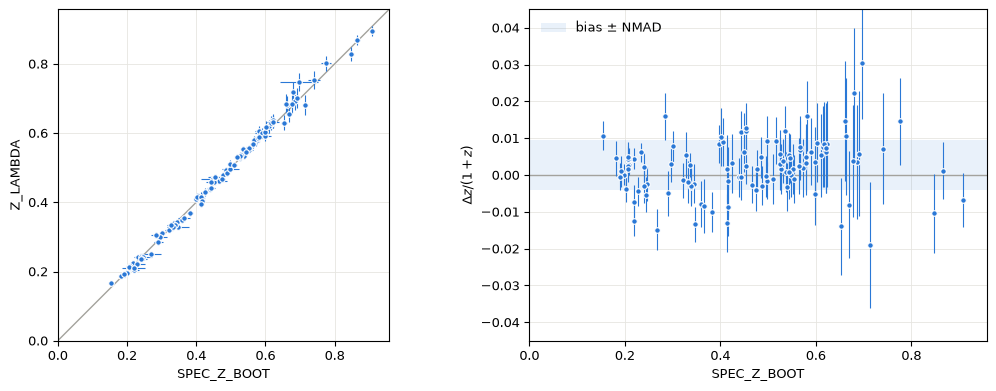

In [12]:
sel = (lam >= 20) & (cat["N_MEMBERS"] >= 3) & np.isfinite(cat["SPEC_Z_BOOT"])
zs, zse = cat["SPEC_Z_BOOT"][sel], cat["SPEC_ZERR_BOOT"][sel]
dz = (zl[sel] - zs) / (1 + zs)
bias = np.median(dz)
nmad = 1.4826 * np.median(np.abs(dz - bias))
print(f"{sel.sum()} clusters: bias {bias:+.4f}, NMAD {nmad:.4f}, "
      f"|Δz/(1 + z)| > 0.05: {np.sum(np.abs(dz) > 0.05)}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.8), constrained_layout=True)
ax1.plot([0, 1], [0, 1], color=GREY, lw=1)
ax1.errorbar(zs, zl[sel], xerr=zse, yerr=cat["Z_LAMBDA_E"][sel], fmt="o", ms=4, color=BLUE,
             mec="white", mew=0.8, elinewidth=0.8)
lim = (0.0, max(zs.max(), zl[sel].max()) + 0.05)
ax1.set(xlim=lim, ylim=lim, xlabel="SPEC_Z_BOOT", ylabel="Z_LAMBDA")
ax1.set_aspect("equal")
ax2.axhspan(bias - nmad, bias + nmad, color=BLUE, alpha=0.1, lw=0, label="bias ± NMAD")
ax2.axhline(0, color=GREY, lw=1)
ax2.errorbar(zs, dz, yerr=cat["Z_LAMBDA_E"][sel] / (1 + zs), fmt="o", ms=4, color=BLUE,
             mec="white", mew=0.8, elinewidth=0.8)
ax2.set(xlim=lim, ylim=(-0.045, 0.045), xlabel="SPEC_Z_BOOT", ylabel=r"$\Delta z / (1 + z)$")
ax2.legend(loc="upper left")
plt.show()

### The richest cluster

The cell shows its key columns and its members, coloured by PMEM with the symbol size set
by z-band magnitude, and its five centre candidates with their P_CEN. The circle has radius
R_LAMBDA.

MEM_MATCH_ID 0  RA 0.79826  Dec -6.09167
LAMBDA 112.5 ± 4.1  Z_LAMBDA 0.2406 ± 0.0032  R_LAMBDA 1.024 h⁻¹Mpc  SCALEVAL 1.054  MASKFRAC 0.052
P_CEN 0.514, 0.486, 0.000, 0.000, 0.000  NCENT_GOOD 5  W 1.122
NSPEC 11  N_MEMBERS 10  SPEC_Z_BOOT 0.2330 ± 0.0007  VDISP 612 ± 143 km/s (gapper)  BEST_Z 0.2330 (spec_z_boot)


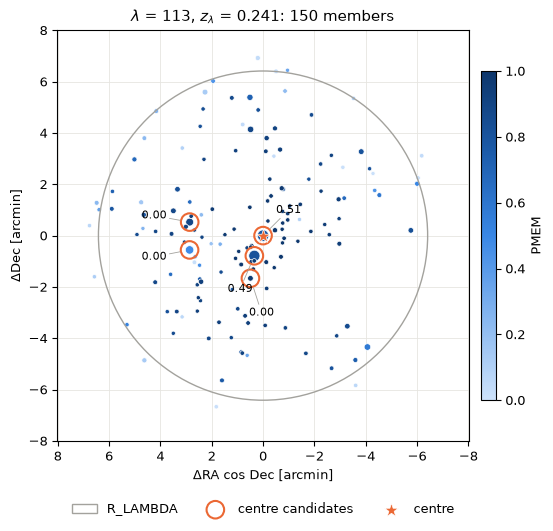

In [13]:
i = int(np.argmax(lam))
cl = {k: v[i] for k, v in cat.items()}
print(f"MEM_MATCH_ID {cl['MEM_MATCH_ID']}  RA {cl['RA']:.5f}  Dec {cl['DEC']:.5f}")
print(f"LAMBDA {cl['LAMBDA']:.1f} ± {cl['LAMBDA_E']:.1f}  Z_LAMBDA {cl['Z_LAMBDA']:.4f} ± "
      f"{cl['Z_LAMBDA_E']:.4f}  R_LAMBDA {cl['R_LAMBDA']:.3f} h⁻¹Mpc  SCALEVAL "
      f"{cl['SCALEVAL']:.3f}  MASKFRAC {cl['MASKFRAC']:.3f}")
print("P_CEN " + ", ".join(f"{p:.3f}" for p in cl["P_CEN"])
      + f"  NCENT_GOOD {cl['NCENT_GOOD']}  W {cl['W']:.3f}")
print(f"NSPEC {cl['NSPEC']}  N_MEMBERS {cl['N_MEMBERS']}  SPEC_Z_BOOT {cl['SPEC_Z_BOOT']:.4f} ± "
      f"{cl['SPEC_ZERR_BOOT']:.4f}  VDISP {cl['VDISP']:.0f} ± {cl['VDISP_ERR']:.0f} km/s "
      f"({cl['VDISP_TYPE']})  BEST_Z {cl['BEST_Z']:.4f} ({cl['BEST_Z_TYPE']})")

m = mem["MEM_MATCH_ID"] == cl["MEM_MATCH_ID"]
cosd = np.cos(np.radians(cl["DEC"]))
dx = (mem["RA"][m] - cl["RA"]) * cosd * 60
dy = (mem["DEC"][m] - cl["DEC"]) * 60
pm, mag = mem["PMEM"][m], mem["REFMAG"][m]
o = np.argsort(pm)
r_lam = cl["R_LAMBDA"] / reg.mpc_per_deg_np(cl["Z_LAMBDA"]) * 60

fig, ax = plt.subplots(figsize=(6, 5.2), constrained_layout=True)
sc = ax.scatter(dx[o], dy[o], c=pm[o], cmap=RAMP, vmin=0, vmax=1,
                s=8 + 60 * 10 ** (-0.4 * (mag[o] - mag.min())), edgecolor="white", lw=0.5)
ax.add_patch(plt.Circle((0, 0), r_lam, fill=False, color=GREY, lw=1, label="R_LAMBDA"))
ok = cl["ID_CENT"] >= 0
cx = (cl["RA_CENT"][ok] - cl["RA"]) * cosd * 60
cy = (cl["DEC_CENT"][ok] - cl["DEC"]) * 60
ax.set(xlim=(1.25 * r_lam, -1.25 * r_lam), ylim=(-1.25 * r_lam, 1.25 * r_lam),
       xlabel="ΔRA cos Dec [arcmin]", ylabel="ΔDec [arcmin]",
       title=rf"$\lambda$ = {cl['LAMBDA']:.0f}, $z_\lambda$ = {cl['Z_LAMBDA']:.3f}: {m.sum()} members")
ax.set_aspect("equal")
label_candidates(ax, cx, cy, cl["P_CEN"][ok])
ax.scatter(0, 0, marker="*", s=110, color=ORANGE, edgecolor="white", lw=0.5, zorder=4,
           label="centre")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3)
fig.colorbar(sc, cax=ax.inset_axes([1.03, 0.1, 0.035, 0.8]), label="PMEM")
plt.show()

## Cross-check with ACT

When the sweeps contain it, the SZ cluster ACT-CL J0012.9-0857 (Hilton et al. 2021,
z = 0.352) serves as an external check. The cell lists the rema clusters centred within 3′
of its SZ position, and the centring of the richest of them. The scan notebook measures the
same cluster from its position alone.

In [14]:
if SKY.contains(ACT.ra.deg, ACT.dec.deg):
    Z_ACT = 0.352
    sep = SkyCoord(cat["RA"], cat["DEC"], unit="deg").separation(ACT).arcmin
    near = np.flatnonzero(sep < 3)
    near = near[np.argsort(sep[near])]
    cols = ("MEM_MATCH_ID", "LAMBDA", "Z_LAMBDA", "Z_LAMBDA_E", "SPEC_Z_BOOT", "N_MEMBERS", "VDISP")
    tab = Table({"SEP_ARCMIN": sep[near], **{k: cat[k][near] for k in cols}})
    for col, fmt in (("SEP_ARCMIN", ".2f"), ("LAMBDA", ".1f"), ("Z_LAMBDA", ".4f"),
                     ("Z_LAMBDA_E", ".4f"), ("SPEC_Z_BOOT", ".4f"), ("VDISP", ".0f")):
        tab[col].format = fmt
    tab.pprint(max_width=-1)
    j = near[np.argmax(lam[near])]
    off = sep[j] / 60 * reg.mpc_per_deg_np(zl[j])
    ok = cat["ID_CENT"][j] >= 0
    cand = SkyCoord(cat["RA_CENT"][j][ok], cat["DEC_CENT"][j][ok], unit="deg").separation(ACT).arcmin
    print(f"\nrichest within 3′: λ {lam[j]:.1f}, centred {sep[j]:.2f}′ = {off:.2f} h⁻¹Mpc from the SZ position")
    print("centre candidates: " + ", ".join(f"{s:.2f}′ (P_CEN {p:.3f})"
                                            for s, p in zip(cand, cat["P_CEN"][j][ok])))
    print(f"(Z_LAMBDA − z_ACT)/(1 + z_ACT) = {(zl[j] - Z_ACT) / (1 + Z_ACT):+.4f}, "
          f"(SPEC_Z_BOOT − z_ACT)/(1 + z_ACT) = {(cat['SPEC_Z_BOOT'][j] - Z_ACT) / (1 + Z_ACT):+.4f}")
else:
    print("ACT-CL J0012.9-0857 is not in these sweeps")

SEP_ARCMIN MEM_MATCH_ID LAMBDA Z_LAMBDA Z_LAMBDA_E SPEC_Z_BOOT N_MEMBERS VDISP
---------- ------------ ------ -------- ---------- ----------- --------- -----
      0.85         8637    3.7   0.3424     0.0080      0.3384         5   715
      2.05         3240    6.9   0.8675     0.0342         nan         0   nan
      2.42            1  107.0   0.3401     0.0043      0.3365        15   822
      2.90         7311    4.1   0.7902     0.0328         nan         0   nan

richest within 3′: λ 107.0, centred 2.42′ = 0.49 h⁻¹Mpc from the SZ position
centre candidates: 2.42′ (P_CEN 0.646), 2.07′ (P_CEN 0.275), 3.93′ (P_CEN 0.074), 0.85′ (P_CEN 0.003), 1.31′ (P_CEN 0.002)
(Z_LAMBDA − z_ACT)/(1 + z_ACT) = -0.0088, (SPEC_Z_BOOT − z_ACT)/(1 + z_ACT) = -0.0115


For this cluster, the members' spectroscopic redshifts and z_λ agree with each other, and
both lie about 0.01 (1 + z) below the ACT redshift. No spectroscopic redshift within 6′ is
near the ACT value (see the scan notebook). Blind mode centres the cluster on its brightest
member, which lies outside the 0.4 h⁻¹Mpc search radius that scan mode uses around an input
position.

## The production catalogue

The DR11 south production run used the same calibration, configuration, galaxies and
randoms over the whole footprint, as regions of about 100 deg² with 2° buffers. Its merged
catalogues are on the data system next to the sweeps (`PRODUCTS`), in two parts that meet at
RA 0° and 240° and at Dec −85°. Inside these sweeps, its clusters should be the clusters of
this notebook. Near the edges of the sweeps they may differ: the production run also had the
galaxies beyond them, except across the boundaries of the two parts.

The cell matches the clusters by their central galaxy (ID_CENT[0]) and compares them as a
function of the distance to the edge of the sweeps (of their bounding box when they do not
tile a rectangle).

In [15]:
import json

from rema.io.tables import read_catalog


def production_catalogue(sky):
    """Clusters of the production parts centred in ``sky``, with the part number (PART)."""
    parts = []
    for k, run in enumerate(RUNS):
        f = run / "clusters_dr11.fits"
        if not f.exists():
            print(f"{run.name}: not available yet")
            continue
        pc, _, _ = read_catalog(f, members=False)
        qa = json.loads((run / "clusters_dr11_qa.json").read_text())
        keep = sky.contains(pc["RA"], pc["DEC"])
        parts.append({**{c: np.asarray(v)[keep] for c, v in pc.items()}, "PART": np.full(int(keep.sum()), k)})
        same = qa.get("calibrations") == [file_sha1(CALIB)]
        print(f"{run.name}: {len(pc['RA']):,} clusters, {int(keep.sum()):,} in these sweeps; "
              f"{'same' if same else 'another'} calibration")
    return {c: np.concatenate([q[c] for q in parts]) for c in parts[0]} if parts else None


prod = production_catalogue(SKY)
if prod is not None and len(prod["RA"]):
    where = {k: i for i, k in enumerate(np.asarray(prod["ID_CENT"])[:, 0])}
    j = np.array([where.get(k, -1) for k in np.asarray(cat["ID_CENT"])[:, 0]])
    b = SKY.bounding()
    cosd = np.cos(np.radians(cat["DEC"]))
    edge = np.minimum.reduce([cat["DEC"] - b.dec_min, b.dec_max - cat["DEC"],
                              (cat["RA"] - b.ra_min) * cosd, (b.ra_max - cat["RA"]) * cosd])
    rows = []
    for lo, hi in ((0.0, 1.0), (1.0, 2.3), (2.3, 99.0)):
        s = (lam >= 20) & (edge >= lo) & (edge < hi)
        m = s & (j >= 0)
        rel = np.abs(prod["LAMBDA"][j[m]] / lam[m] - 1)
        dz = np.abs(prod["Z_LAMBDA"][j[m]] - zl[m])
        rows.append((f"{lo:.1f}-{hi:.1f}", int(s.sum()), m.sum() / max(s.sum(), 1),
                     np.median(rel) if m.any() else np.nan, dz.max() if m.any() else np.nan))
    tab = Table(rows=rows, names=("EDGE_DEG", "N_LAMBDA_GE_20", "SAME_CENTRE", "MEDIAN_DLAMBDA_REL", "MAX_DZ"))
    for col, fmt in (("SAME_CENTRE", ".1%"), ("MEDIAN_DLAMBDA_REL", ".2e"), ("MAX_DZ", ".1e")):
        tab[col].format = fmt
    tab.pprint(max_width=-1)
    lp = np.asarray(prod["LAMBDA"])
    print(f"production clusters with λ ≥ 20 in these sweeps: {int(np.sum(lp >= 20))}, "
          f"this notebook: {int(np.sum(lam >= 20))}")

rema_dr11_v0.2.0_ra0-240: 2,453,256 clusters, 11,625 in these sweeps; same calibration
rema_dr11_v0.2.0_ra240-360: not available yet
EDGE_DEG N_LAMBDA_GE_20 SAME_CENTRE MEDIAN_DLAMBDA_REL  MAX_DZ
-------- -------------- ----------- ------------------ -------
 0.0-1.0            203      100.0%           3.48e-06 1.4e-01
 1.0-2.3            146      100.0%           2.74e-06 1.4e-05
2.3-99.0             20      100.0%           2.96e-06 4.5e-06
production clusters with λ ≥ 20 in these sweeps: 374, this notebook: 369


## Runtimes

In [16]:
for step, sec in T.items():
    print(f"{step:10s} {sec:7.1f} s")
print(f"{'total':10s} {sum(T.values()):7.1f} s on {jax.devices()[0].device_kind}")

ingest        77.4 s
footprint    895.4 s
zred          10.3 s
blind       1370.6 s
specpost     136.4 s
total       2490.1 s on Tesla V100-SXM2-32GB


## The same run from the command line

Repeat `--box` once per box of the sky; the sweeps here tile a single rectangle.

```bash
rema ingest $REMA_DATA/sweep/11.0/sweep-000m005-005p000.fits \
     $REMA_DATA/sweep/11.0/sweep-000m010-005m005.fits \
     $REMA_DATA/sweep/11.0/sweep-000m015-005m010.fits --outdir galaxies
rema maps $REMA_DATA/randoms/randoms-south-1-*.fits --box 0 5 -15 0 --out footprint.fits
rema blind --galaxies galaxies --box 0 5 -15 0 --calib CALIB --footprint footprint.fits \
     --checkpoint checkpoint --specpost --out clusters.fits
```

- **Configuration:** `rema blind` uses the configuration stored in the calibration unless
  `--config` is given. `rema ingest` and `rema maps` have none to read, so pass them
  `--config` when the calibration was made with a non-default configuration (write it with
  `cal.config.to_yaml("config.yaml")`).
- **GPU:** set `JAX_PLATFORMS=cuda`.